In [7]:
import pandas as pd
import numpy as np

from math import isnan
import multiprocessing as mp
import matplotlib.pyplot as plt
import json
from protocols import utils, functions, graphs
from matplotlib_venn import venn2
from functools import partial
from joblib import Memory
from multiprocessing import Pool, get_context
import multiprocessing as mp

import gumpy


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Compare contents of WHOv1 vs catomatic-1, as trained on same data

The comparison is complicated by the fact catomatic-1 does not contain rules and WHOv1 does - its an assymetric comparison.

We want to show the effect of removing rules from WHOv1 as well as the effect of the ruels.

The only way to determine how many variants are captured by a generlisable rule, is to constrain the application of the rules to the training set. 

The function expand_catalogue_pair, does this by applying both catalogues to the training set and counting how many variants have definitive predictions.

In [8]:
def load_who_catalogue(path):
    #Prep data for comparisons:
    who = pd.read_csv(path)
    who['EVIDENCE'] = who['EVIDENCE'].apply(utils.str_to_dict)
    who['GENBANK_REFERENCE'] = 'NC00962.3'
    who['CATALOGUE_VERSION'] = 0
    who['CATALOGUE_NAME'] = '-'
    #filter out default rules
    who = who[~who['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'reporting_rule' in x)]
    return who

who = load_who_catalogue('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv')
who['solo_R'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_R'))
who['solo_S'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_S'))
who['TOTAL'] = who['solo_R'] + who['solo_S']
who['PROPORTION'] = who['solo_R']/(who['solo_R']+who['solo_S'])
who['CONFIDENCE'] = who.apply(utils.wilson_ci, R_col='solo_R', S_col='solo_S', axis=1)
u_who = who[~who.PREDICTION.isin(['R','S'])]
who = who[who.PREDICTION.isin(['R','S'])]

def load_catomatic_catalogues(opt_path, base_path):
    """Load and process catomatic catalogues from optimal parameter settings."""
    opt_df = pd.read_csv(opt_path)
    valid_drugs = opt_df

    # Load catalogue files based on optimal settings
    catalogue_dfs = valid_drugs.apply(
        lambda row: pd.read_csv(
            f"{base_path}/{row['DRUG'].lower()}/bg_{row['BACKGROUND_RATE']}_p_{row['conf_level']}_FRS_0.1.csv"
        ),
        axis=1
    ).tolist()

    cat_df = pd.concat(catalogue_dfs)
    cat_df['CATALOGUE_VERSION'] = 0
    cat_df['CATALOGUE_NAME'] = '-'

    # Parse evidence
    cat_df['EVIDENCE'] = cat_df['EVIDENCE'].apply(utils.str_to_dict)
    cat_df = cat_df[~cat_df['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'default_rule' in x)]

    # Extract key metrics
    cat_df['solo_R'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 0))
    cat_df['solo_S'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 1))
    cat_df['TOTAL'] = cat_df['solo_R'] + cat_df['solo_S']
    cat_df['PROPORTION'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'proportion'))
    cat_df['CONFIDENCE'] = cat_df['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'confidence'))

    # Keep only R and S predictions
    unknown = cat_df[~cat_df.PREDICTION.isin(['R', 'S'])]
    cat_df = cat_df[cat_df.PREDICTION.isin(['R', 'S'])]

    return cat_df, unknown

# Load both catalogue sets
cat, u_cat = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv',
    './catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search'
)

valid_drugs = cat.DRUG.unique()
valid_drugs = np.delete(valid_drugs, np.where(valid_drugs == 'CIP'))

catalogue_palette = {
    "catomatic_v1": "#70c0b3", 
    "catomatic_v3": "#018571",  
    "WHOv1": "#d5b477",        
    "WHOv2": "#a6611a",        
}

In [9]:
valid_drugs_filt = [i for i in valid_drugs if i not in ['PZA', 'ETH']]

/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/functions.py:391: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for key, val in mapping.items()
/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/functions.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat2_no_rules = cat2[~cat2["MUTATION"].str.contains(r"[*?=]", regex=True)]


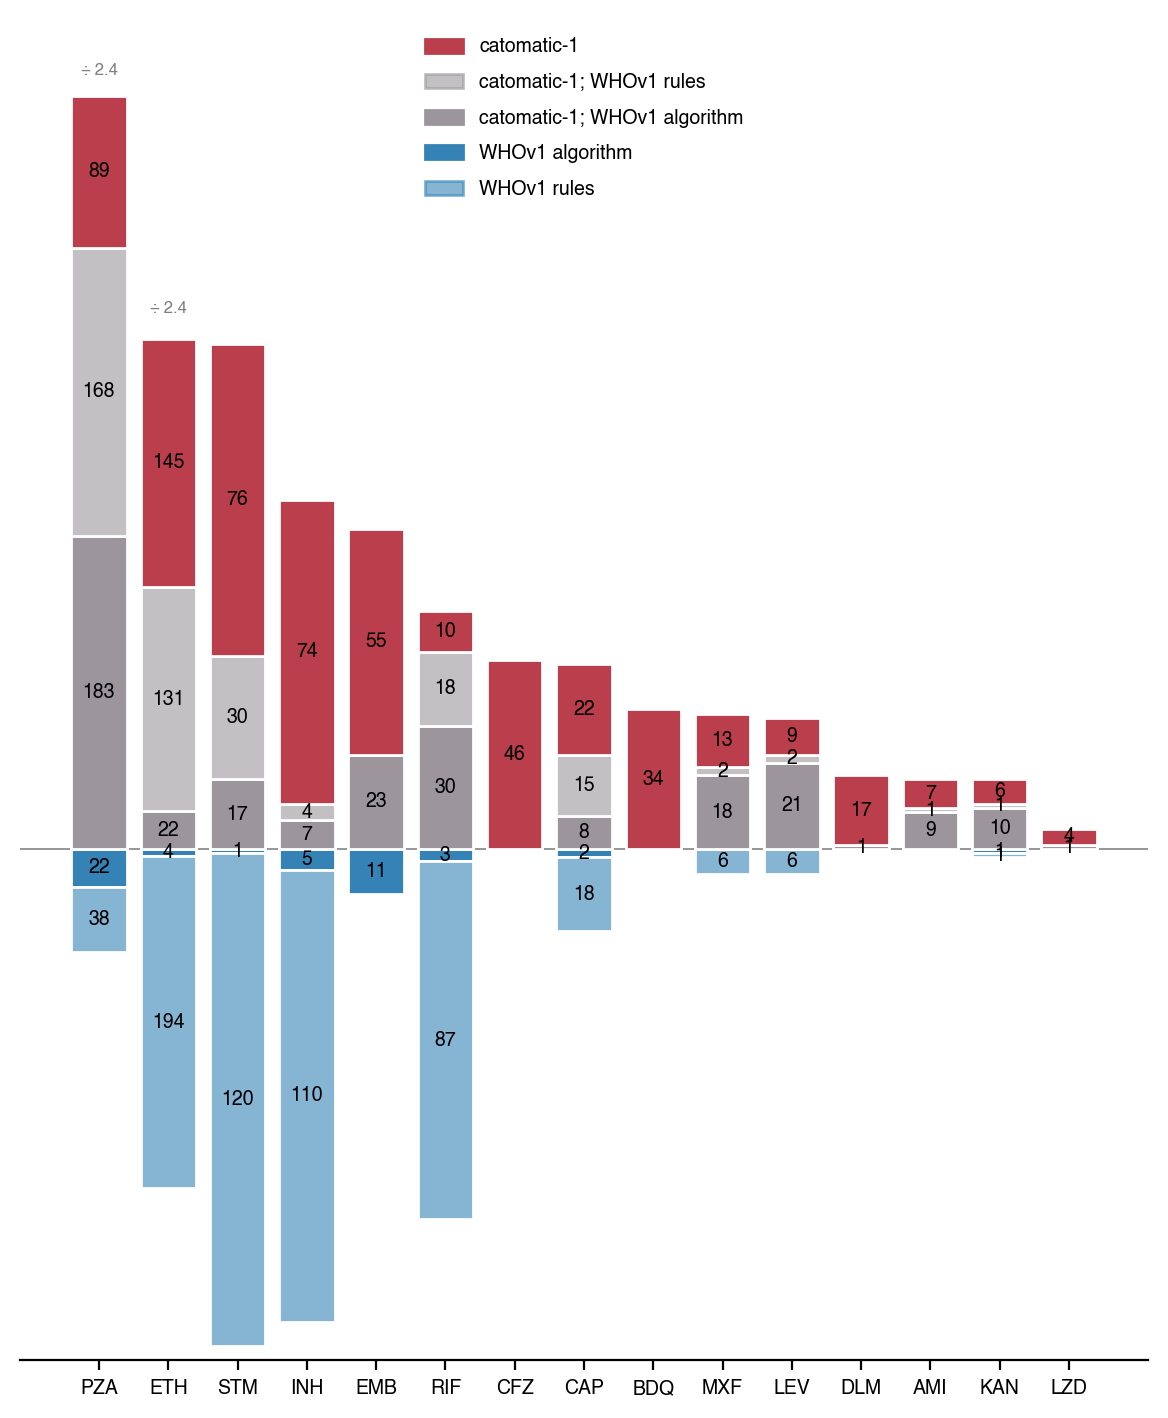

In [22]:
expanded_catalogues = functions.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'), who_cat='WHOv1')
graphs.plot_floating_bars(expanded_catalogues, valid_drugs, figsize=(5.85, 7.1), legend=True)

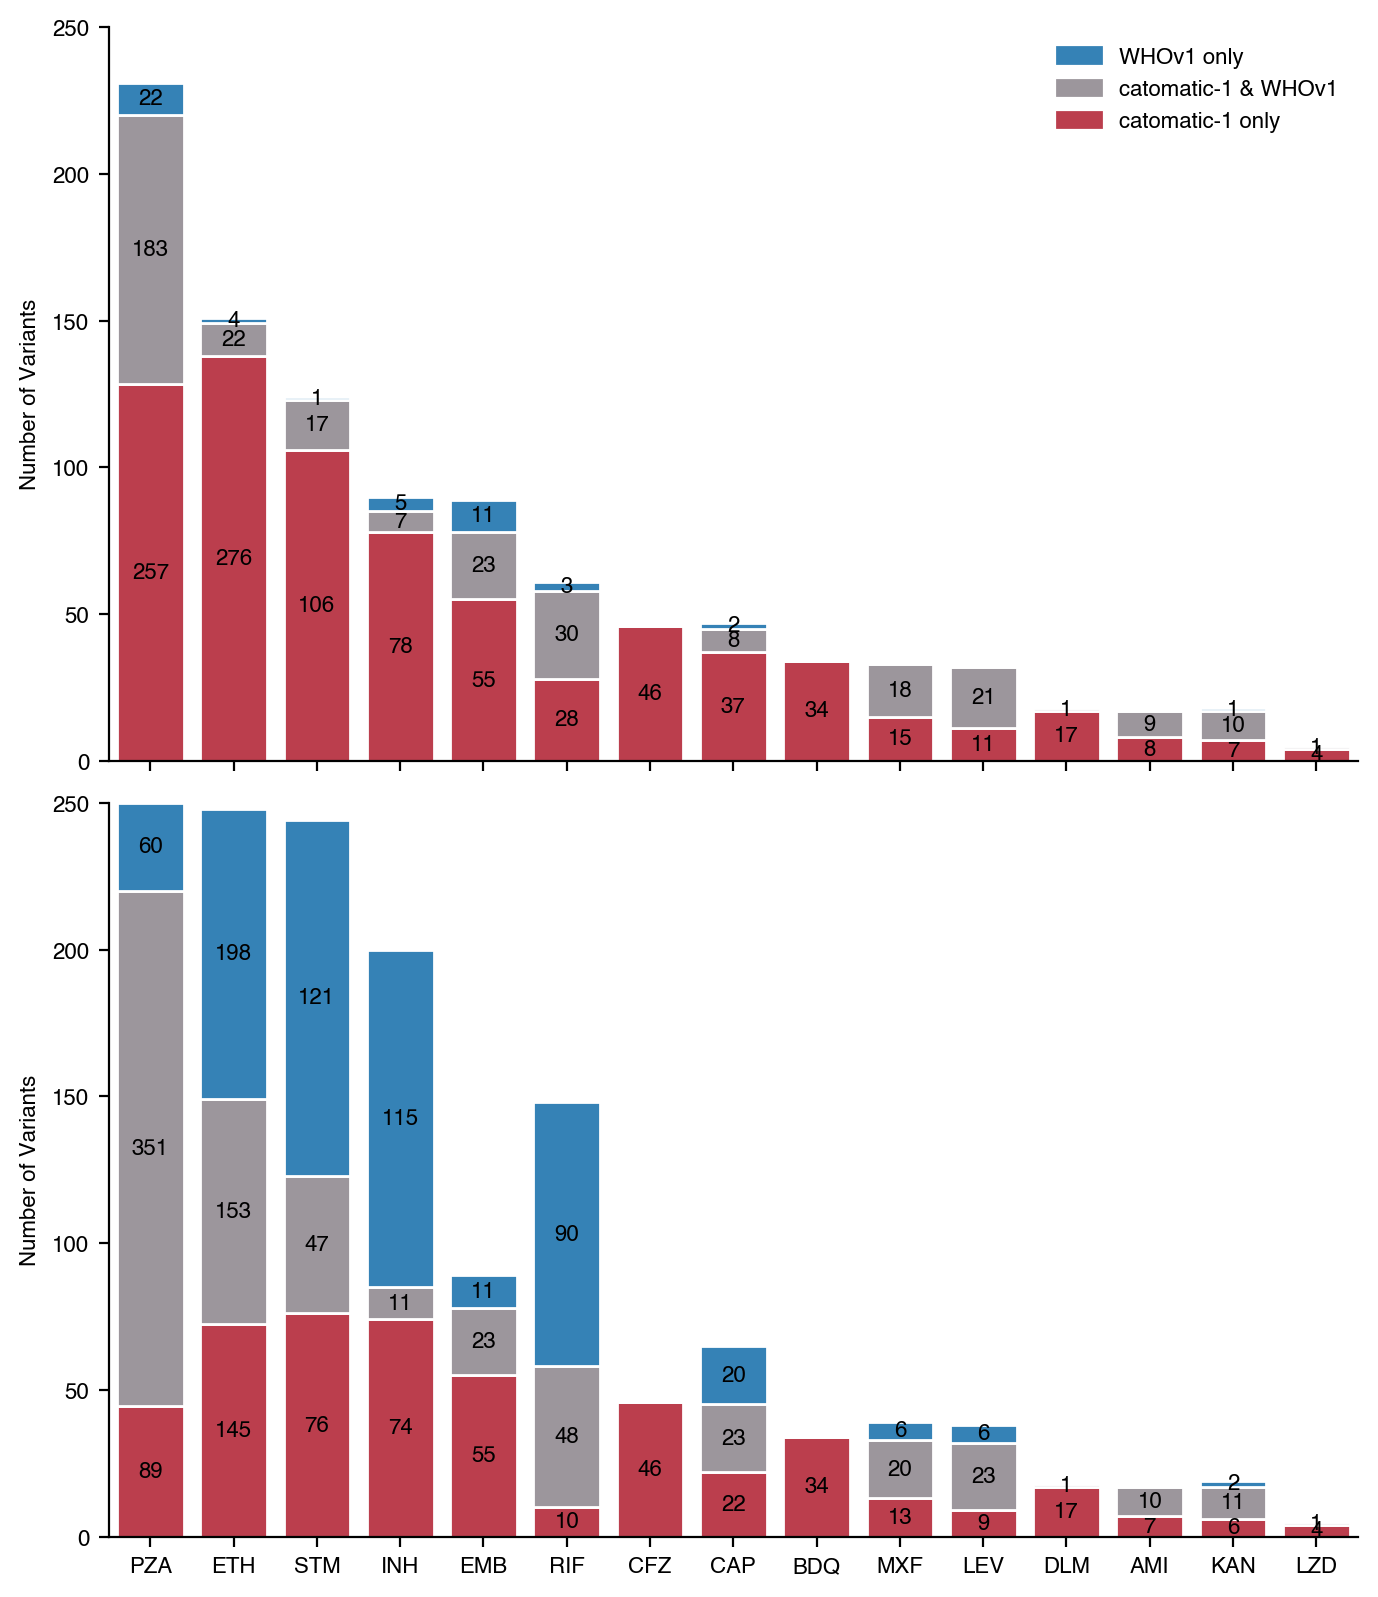

In [50]:
graphs.plot_bar_charts(
expanded_catalogues, valid_drugs, figsize=(6.9, 8), legend=True
)

In [13]:
cryptic_tables_path = "data/cryptic-tables-v3.4.0/"

with open("data/drug_to_genes.json", "r") as f:
    drug_genes = json.load(f)


def process_pair_coverage(args):
    """
    Build pair coverages for one drug.
    """
    drug, genes, cat, who = args

    mutations = functions.prep_mutations(
        "data/mutations-v3.4.0/",
        genes,
        version="v3.4.0",
        mut_path=cryptic_tables_path + "MUTATIONS.parquet",
        var_path=cryptic_tables_path + "VARIANTS.parquet",
        train=True,
    )

    phenotypes = functions.prep_phenotypes(
        drug,
        cryptic_tables_path + "DST_MEASUREMENTS.parquet",
        cryptic_tables_path + "WGS_SAMPLES.parquet",
        version="v3.4.0",
        validation=False,
    )

    pair_cov = functions.expand_pair_coverages(
        cat, who, mutations, phenotypes, drug, "RUS", who_cat="WHOv1"
    )

    return drug, pair_cov


def parallel_pair_coverages(drug_genes, cat, who, valid_drugs, n_cores=4):
    """
    Compute pair coverages for all valid drugs in parallel.
    """
    # Build tasks
    tasks = [(drug, drug_genes[drug]["genes"], cat, who) for drug in valid_drugs]

    ctx = mp.get_context("fork")   # Linux/Mac
    num_workers = min(n_cores, len(tasks))

    with ctx.Pool(num_workers) as pool:
        results = list(pool.imap(process_pair_coverage, tasks))

    # Reassemble dictionary
    pair_coverages = {drug: pair_cov for drug, pair_cov in results}

    return pair_coverages


pair_coverages = parallel_pair_coverages(drug_genes, cat, who, valid_drugs, n_cores=8)
expanded_catalogues = functions.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'), who_cat='WHOv1')


/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/functions.py:608: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/functions.py:618: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/functions.py:608: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

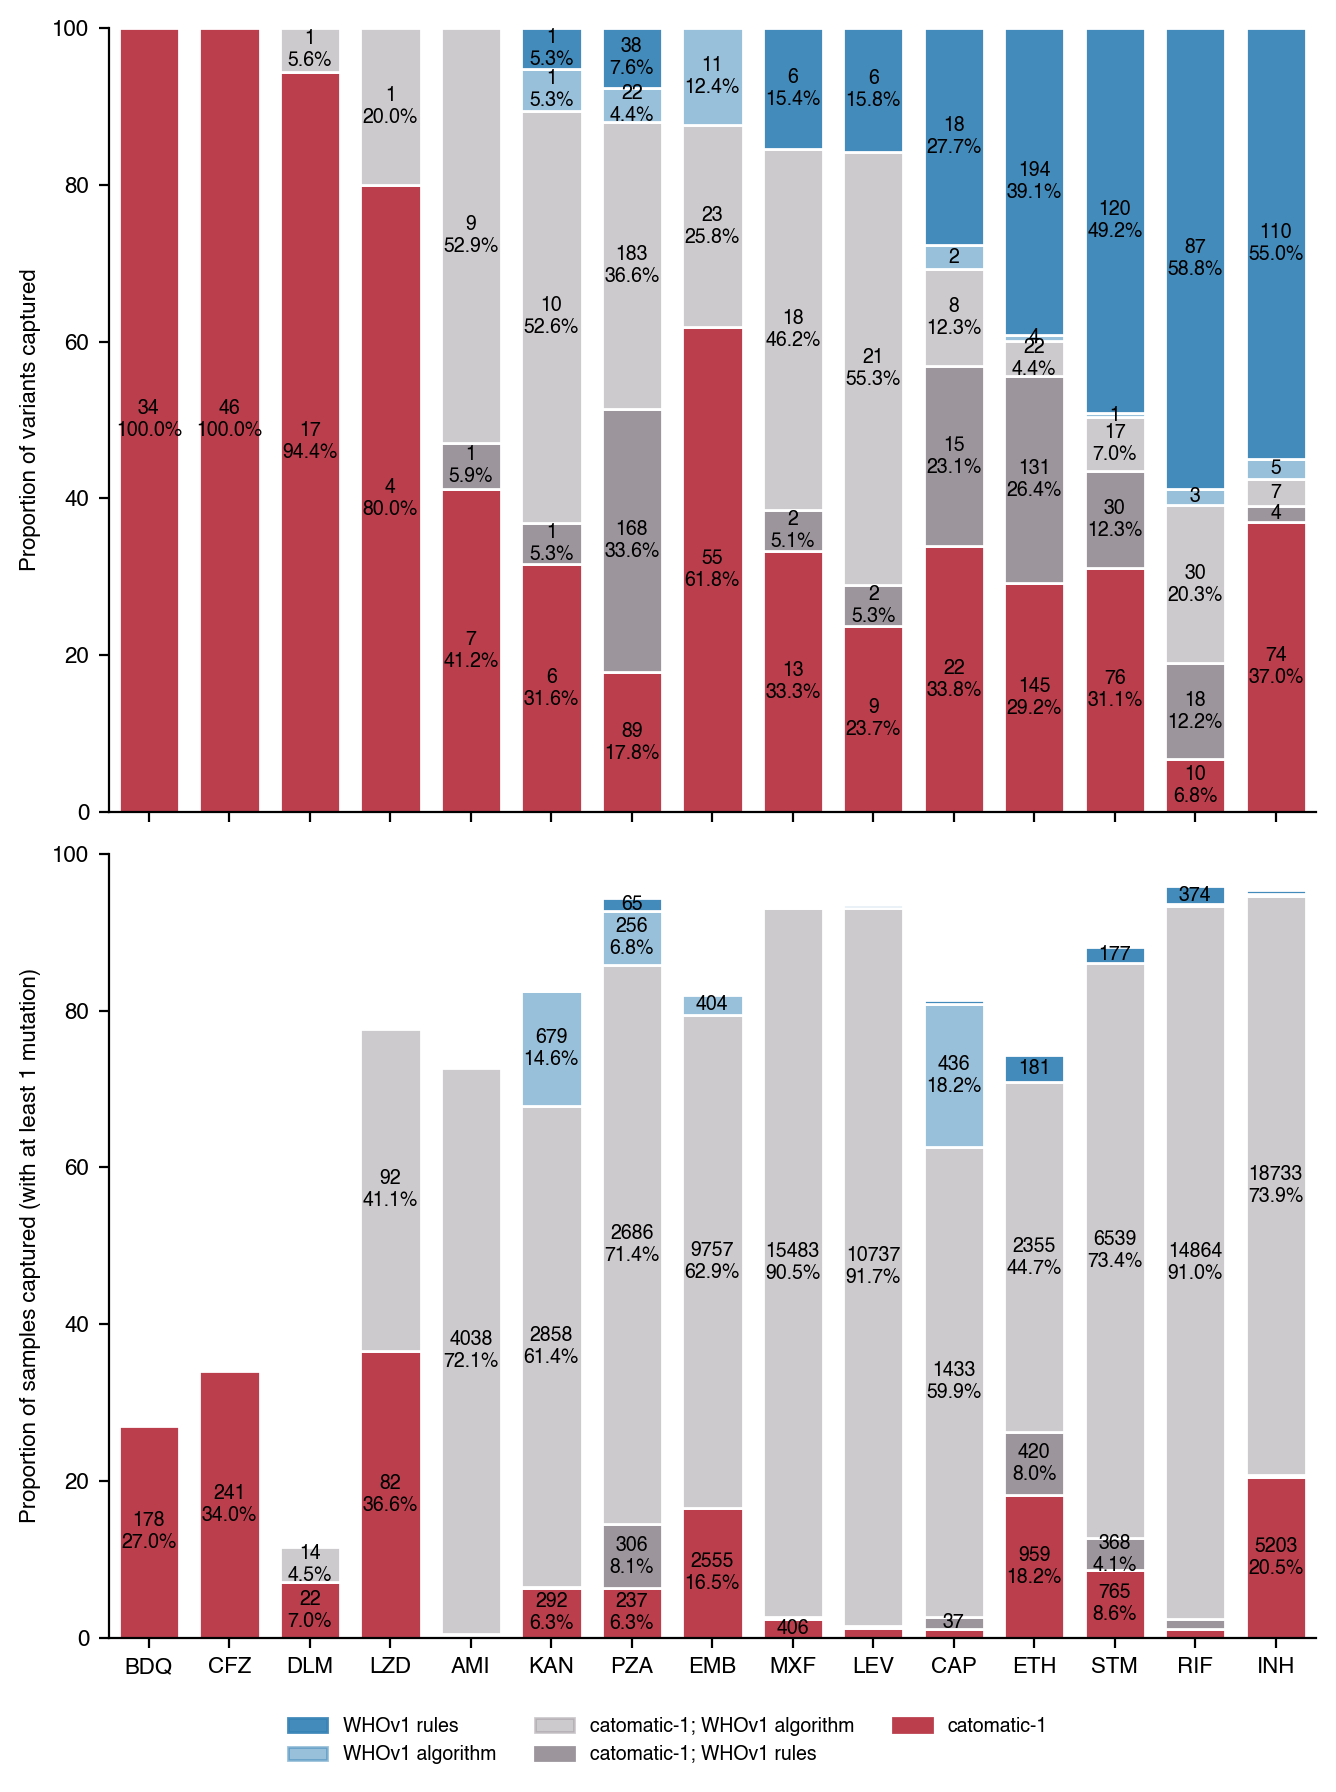

In [14]:
graphs.plot_stacked_percentage_bars(expanded_catalogues, pair_coverages, valid_drugs, legend=True, figsize=(6.69, 8.5))

## Summary table including rules

In [16]:
expanded_catalogues = functions.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'), who_cat='WHOv1')
all_drugs_merged = pd.concat(expanded_catalogues[drug]['merged'] for drug in valid_drugs)
suffixes = ('cat', 'who')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged['DRUG'] = all_drugs_merged['DRUG_who'].combine_first(all_drugs_merged['DRUG_cat'])

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, including rules:')
summary_table

/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/functions.py:391: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for key, val in mapping.items()
/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/functions.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat2_no_rules = cat2[~cat2["MUTATION"].str.contains(r"[*?=]", regex=True)]


Prediction pairs comparing catomatic_v1 with WHOv1, including rules:


,DRUG,R.R,R.S,R.U,S.R,S.S,S.U,U.R,U.S,total
0,AMI,4,0,7,0,6,0,0,0,17
1,BDQ,0,0,34,0,0,0,0,0,34
2,CAP,21,0,22,0,2,0,18,2,65
3,CFZ,0,0,46,0,0,0,0,0,46
4,DLM,1,0,17,0,0,0,0,0,18
5,EMB,12,0,8,0,11,47,3,8,89
6,ETH,153,0,145,0,0,0,198,0,496
7,INH,10,0,52,0,1,22,112,3,200
8,KAN,8,0,3,0,3,3,0,2,19
9,LEV,10,0,3,0,13,6,4,2,38


In [17]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

# Example usage:
drug = "STM"
cat_pheno = 'R'
who_pheno = np.nan
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG==drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,Unnamed: 0_cat,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG_cat,MUTATION,PREDICTION_cat,SOURCE_cat,...,EVIDENCE_who,OTHER_who,Unnamed: 0_who,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR,DRUG
0,266.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@-33_del_t,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
146,188.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A119D,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
147,300.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A133P,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
149,275.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A138E,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
150,128.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A138P,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,137.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@a514t,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
267,551.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@a907c,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
268,191.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@a907t,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM
271,502.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@c513t,R,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R.U,STM


## Summary table exlcuding rules

In [18]:
all_drugs_who = pd.concat(expanded_catalogues[drug]['who'] for drug in valid_drugs)
all_drugs_who = all_drugs_who[all_drugs_who.PREDICTION!='U']
all_drugs_cat = pd.concat(expanded_catalogues[drug]['cat'] for drug in valid_drugs)
all_drugs_cat = all_drugs_cat[all_drugs_cat.PREDICTION!='U']

suffixes = ('_cat', '_who')

all_drugs_merged = pd.merge(all_drugs_cat, all_drugs_who, on=['DRUG', 'MUTATION'], how='outer', suffixes=suffixes)
suffixes = ('cat', 'who')

all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged = all_drugs_merged[all_drugs_merged.EVIDENCE_who!={'expanded_rule'}]

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, excluding rules:')
summary_table

Prediction pairs comparing catomatic_v1 with WHOv1, excluding rules:


,DRUG,R.R,R.S,R.U,S.S,S.U,U.R,U.S,U.U,total
0,AMI,3,0,8,6,0,0,0,0,17
1,BDQ,0,0,34,0,0,0,0,0,34
2,CAP,6,0,36,2,0,0,2,0,46
3,CFZ,0,0,46,0,0,0,0,0,46
4,DLM,1,0,17,0,0,0,0,0,18
5,EMB,12,0,8,11,47,3,8,0,89
6,ETH,22,0,237,0,0,4,0,0,263
7,INH,6,0,56,1,22,2,3,0,90
8,KAN,7,0,4,3,3,0,1,0,18
9,LEV,8,0,5,13,6,0,0,0,32


In [19]:
def nan_friendly_filter(series, value):
    if pd.isna(value):
        return series.isna()
    else:
        return series == value

drug = "STM"
cat_pheno = 'S'
who_pheno = np.nan 
#np.nan

all_drugs_merged[
    (all_drugs_merged.DRUG == drug) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_who, who_pheno) &
    nan_friendly_filter(all_drugs_merged.PREDICTION_cat, cat_pheno)
]

,Unnamed: 0_cat,GENBANK_REFERENCE_cat,CATALOGUE_NAME_cat,CATALOGUE_VERSION_cat,CATALOGUE_GRAMMAR_cat,PREDICTION_VALUES_cat,DRUG,MUTATION,PREDICTION_cat,SOURCE_cat,...,SOURCE_who,EVIDENCE_who,OTHER_who,Unnamed: 0_who,solo_R_who,solo_S_who,TOTAL_who,PROPORTION_who,CONFIDENCE_who,PREDICTION_PAIR
1286,3.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@A205T,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U
1361,2.0,NC00962.3,-,0.0,GARC1,RUS,STM,gid@c-11t,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U
1371,6.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@c1443g,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U
1377,4.0,NC00962.3,-,0.0,GARC1,RUS,STM,rrs@t-4g,S,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S.U


# Compare catomatic on training set vs catomatic on entire dataset

In [20]:
# Load both catalogue sets
cat, u_cat = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv',
    './catalogues/MTBC-CRyPTICv1.1.1-2025.8/grid_search'
)

cats_all, u_cats_all = load_catomatic_catalogues(
    'results/grid_search/opt_cats_MTBC-CRyPTICv1.1.1-2025.8.csv', 
    './catalogues/MTBC-CRyPTICv3.4.0-2025.8/grid_search'
)

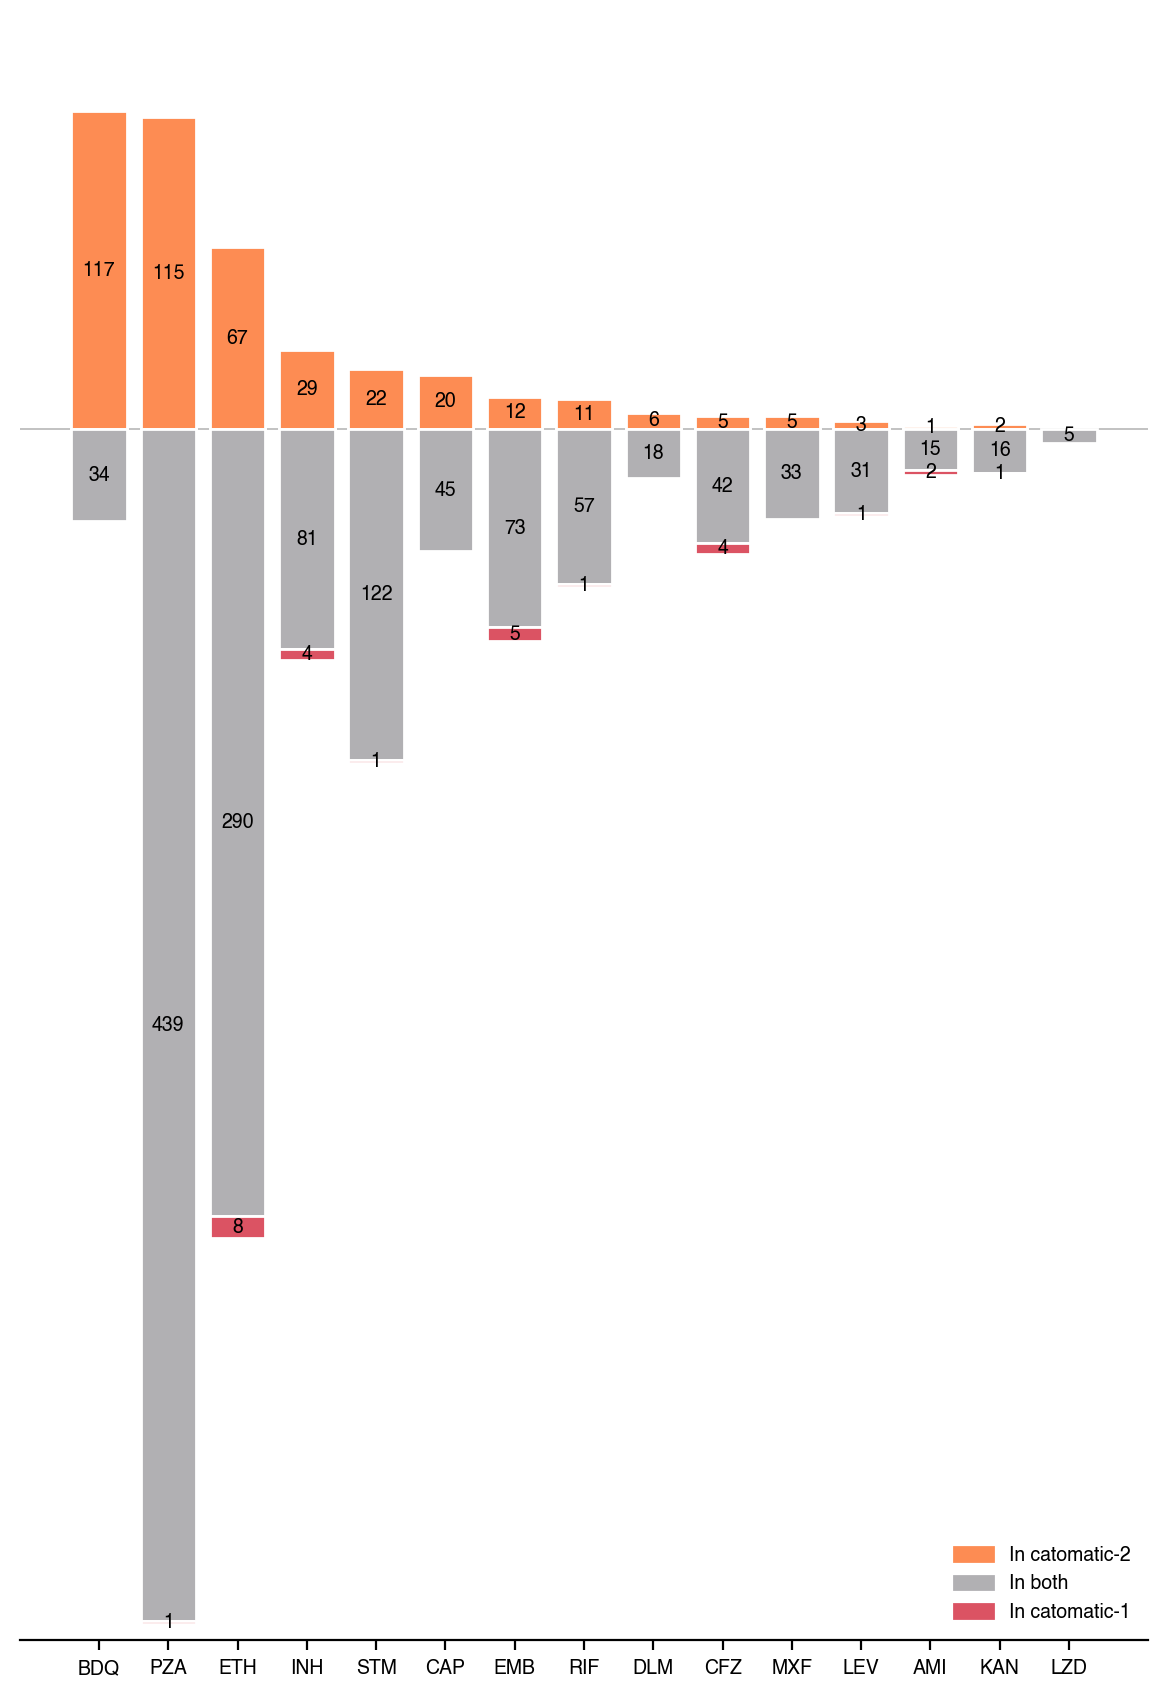

In [21]:
expanded_catalogues = functions.expand_catalogue_pair(cat, cats_all, valid_drugs, 'RUS', ('cat', 'cats_all'), who_cat=None)
graphs.plot_floating_bars_cat_vs_cats_all(expanded_catalogues, valid_drugs, figsize=(5.85, 8.5), legend=True)


In [19]:
print ('number of rows more in catalogue trained on all data:', len(cats_all)-len(cat))

number of rows more in catalogue trained on all data: 387
